In [1]:
import csv
import sys
import os
import pandas as pd

IN_COLAB = "COLAB_GPU" in os.environ
if IN_COLAB:
    !git clone https://github.com/sinskid/deep_learning_project.git
    %cd deep_learning_project
    !pip install -r requirements.txt

repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_path not in sys.path:
    sys.path.append(repo_path)

import python.data as d
from python.models import get_cnn , get_vit, accuracy_per_class1, accuracy_per_class2, accuracy1, accuracy2
from python.utils import setup_dirs, labels_to_names

import torch
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

In [2]:
# Set up directories for logs
paths = setup_dirs()

accuracy1_path = os.path.join(paths["logs"], "accuracy1.csv")
accuracy2_path = os.path.join(paths["logs"], "accuracy2.csv")
accuracy_byclass1_path = os.path.join(paths["logs"], "accuracy_by_class1.csv")
accuracy_byclass2_path = os.path.join(paths["logs"], "accuracy_by_class2.csv")

# if the csv files doesn't exist, create it and write the header
for path in [accuracy1_path, accuracy2_path]:
    if not os.path.exists(path):
        print(f"Creating {path} and writing header")
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["dataset", "cnn", "vit"])
    else :
        print(f"accuracy file exists")

accuracy1_csv = pd.read_csv(accuracy1_path)
accuracy2_csv = pd.read_csv(accuracy2_path)

for path in [accuracy_byclass1_path, accuracy_byclass2_path]:
    if not os.path.exists(path):
        print(f"Creating {path} and writing header")
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["class", "cnn", "vit"])
else :
    print(f"accuracy by class file exists")

accuracy_byclass1_csv = pd.read_csv(accuracy_byclass1_path)
accuracy_byclass2_csv = pd.read_csv(accuracy_byclass2_path)

# Function to log accuracy results (not used for accuracy by class since it's use one time only)
def log_accuracy(dataset_name, cnn_acc, vit_acc, accuracy_path):
    with open(accuracy_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([dataset_name, f"{cnn_acc:.3f}", f"{vit_acc:.3f}"])

accuracy file exists
accuracy file exists
accuracy by class file exists


In [3]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# Initialize the CNN model and move it to the appropriate device
model_cnn = get_cnn().to(device)

# Initialize the ViT model and move it to the appropriate device
model_vit = get_vit().to(device)

# CNN
model_cnn.load_state_dict(torch.load(os.path.join(paths["models"], "cnn_model.pth"), map_location=device))
model_cnn.eval()

# ViT
model_vit.load_state_dict(torch.load(os.path.join(paths["models"], "vit_model.pth"), map_location=device))
model_vit.eval()

cpu


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


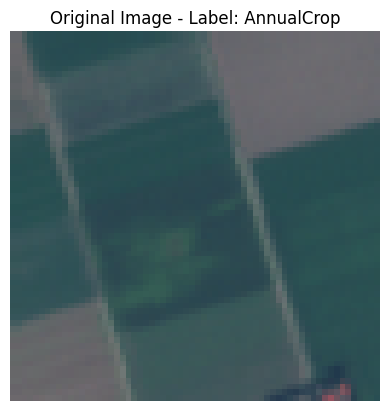

In [4]:
# Depend de CPU ou GPU
num_workers = 6
batch_size = 32

# Image dataset
image_dataloader_test = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "image", data_type = "test")
to_pil = ToPILImage()
image, label = to_pil(next(iter(image_dataloader_test))[0][0]), labels_to_names[next(iter(image_dataloader_test))[1][0].item()]

plt.imshow(image)
plt.title(f"Original Image - Label: {label}")
plt.axis('off')
plt.savefig(os.path.join(paths["images"], "original_image.png"))
plt.show()

# Datasets sans effets
cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "cnn", data_type = "test")
vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "vit", data_type = "test")

In [5]:
# Datasets sans effets
cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "cnn", data_type = "test")
vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "vit", data_type = "test")

if accuracy1_csv["dataset"].str.contains("no effect").any() and accuracy2_csv["dataset"].str.contains("no effect").any():
    print("Results for original images already logged.")

else:
    # test accuracy1
    acc_cnn1 = accuracy1(cnn_dataloader, model_cnn, device)
    acc_vit1 = accuracy1(vit_dataloader, model_vit, device)
    print(f"Test Accuracy1 (CNN): {acc_cnn1:.4f}")
    print(f"Test Accuracy1 (ViT): {acc_vit1:.4f}")
    
# Test accuracy2
    acc_vit2 = accuracy2(vit_dataloader, model_vit, device)
    acc_cnn2 = accuracy2(cnn_dataloader, model_cnn, device)

    log_accuracy("no effect", acc_cnn1, acc_vit1, accuracy1_path)
    log_accuracy("no effect", acc_cnn2, acc_vit2, accuracy2_path)

Results for original images already logged.


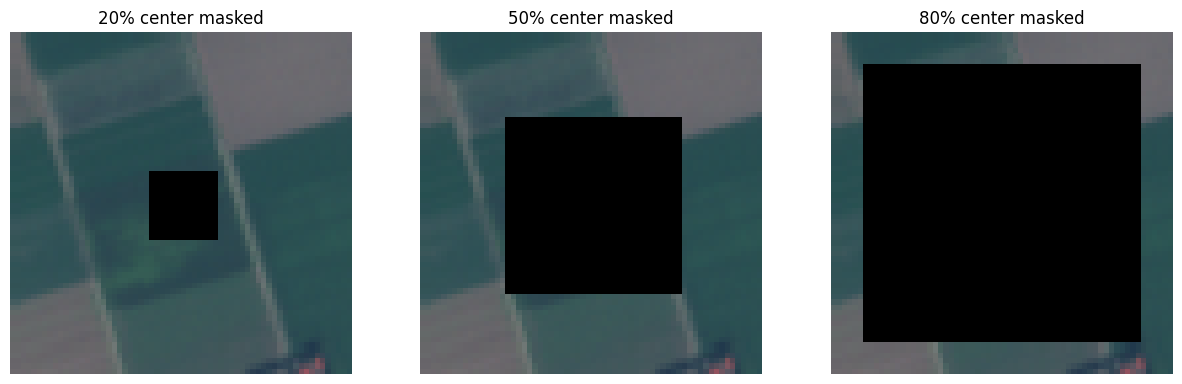

Results for center masked images already logged.


In [6]:
# Datasets avec effets masquage du centre de l'image
mask_percent = [0.2, 0.5, 0.8] 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boucle sur les différents pourcentages de masque
for ax, mask in zip(axes, mask_percent):
    # Modifier l'image en appliquant un effet
    modified_image = d.apply_center_mask(image, mask)
    ax.imshow(modified_image)
    ax.axis('off')  # Masquer les axes
    ax.set_title(f"{int(mask*100)}% center masked")  

plt.savefig(os.path.join(paths["images"], "center_masked_images.png"))
plt.show()

if accuracy1_csv["dataset"].str.contains("center_masked").any() and accuracy2_csv["dataset"].str.contains("center_masked").any():
    print("Results for center masked images already logged.")

else:
    for mask in mask_percent:
        
        # Créer des dataloaders avec l'effet de masque centré
        center_mask_effects = {"center_mask": mask}
        cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=center_mask_effects)
        vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=center_mask_effects)
        
        acc_cnn_effects1 = accuracy1(cnn_dataloader, model_cnn, device)
        acc_vit_effects1 = accuracy1(vit_dataloader, model_vit, device)
        acc_cnn_effects2 = accuracy2(cnn_dataloader, model_cnn, device)
        acc_vit_effects2 = accuracy2(vit_dataloader, model_vit, device)


        print(f"Test Accuracy1 with {int(mask*100)}% Center-Masked Images (CNN): {acc_cnn_effects1:.4f}")
        print(f"Test Accuracy1 with {int(mask*100)}% Center-Masked Images (ViT): {acc_vit_effects1:.4f}")

        log_accuracy(f"{int(mask*100)}_center_masked", acc_cnn_effects1, acc_vit_effects1, accuracy1_path)
        log_accuracy(f"{int(mask*100)}_center_masked", acc_cnn_effects2, acc_vit_effects2, accuracy2_path)

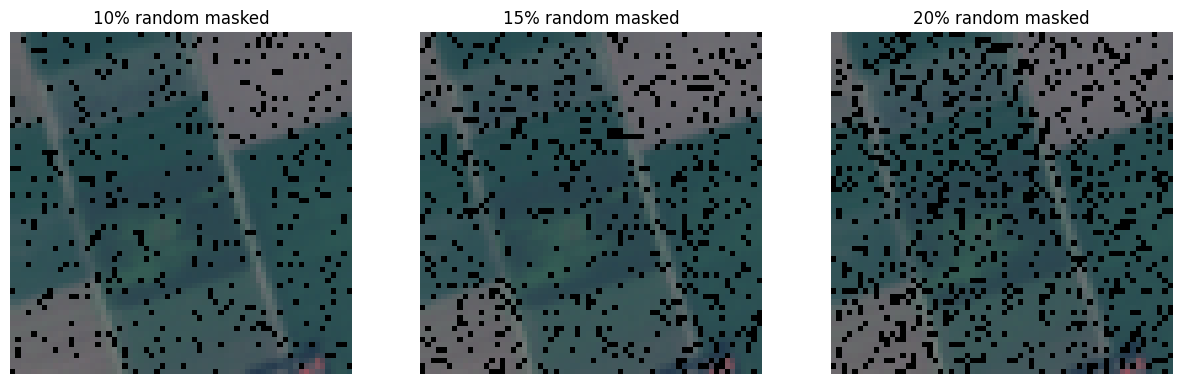

Results for random masked images already logged.


In [7]:
# Datasets avec effets masquage aléatoire de l'image
mask_percent = [0.1, 0.15, 0.2] 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boucle sur les différents pourcentages de masque
for ax, mask in zip(axes, mask_percent):
    # Modifier l'image en appliquant un effet
    modified_image = d.apply_random_mask(image, mask)
    ax.imshow(modified_image)
    ax.axis('off')  # Masquer les axes
    ax.set_title(f"{int(mask*100)}% random masked")  

plt.savefig(os.path.join(paths["images"], "random_masked_images.png"))
plt.show()

if accuracy1_csv["dataset"].str.contains("random_masked").any() and accuracy2_csv["dataset"].str.contains("random_masked").any():
    print("Results for random masked images already logged.")

else:
    for mask in mask_percent:
        
        # Appliquer le masque au centre de l'image et sauvegarder l'image
        print(f"\nTesting with {int(mask*100)}% of random pixels in the image masked:")

        # Créer des dataloaders avec l'effet de masque centré
        random_mask_effects = {"random_mask": mask}
        cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=random_mask_effects)
        vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=random_mask_effects)
        
        acc_cnn_effects1 = accuracy1(cnn_dataloader, model_cnn, device)
        acc_vit_effects1 = accuracy1(vit_dataloader, model_vit, device)
        acc_cnn_effects2 = accuracy2(cnn_dataloader, model_cnn, device)
        acc_vit_effects2 = accuracy2(vit_dataloader, model_vit, device)

        print(f"Test Accuracy1 with {int(mask*100)}% Random-Masked Images (CNN): {acc_cnn_effects1:.4f}")
        print(f"Test Accuracy1 with {int(mask*100)}% Random-Masked Images (ViT): {acc_vit_effects1:.4f}")

        log_accuracy(f"{int(mask*100)}_random_masked", acc_cnn_effects1, acc_vit_effects1, accuracy1_path)
        log_accuracy(f"{int(mask*100)}_random_masked", acc_cnn_effects2, acc_vit_effects2, accuracy2_path)

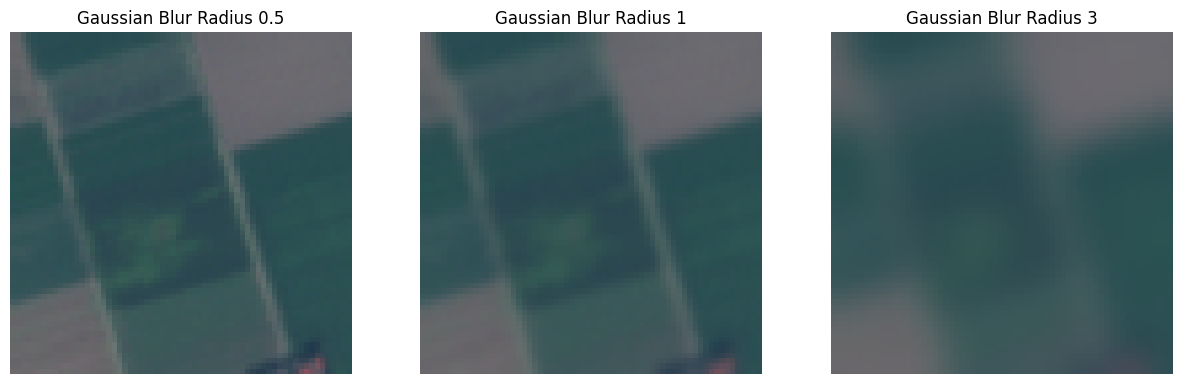

Results for Gaussian Blur images already logged.


In [8]:
# Datasets avec effets masquage aléatoire de l'image
gaussian_blur_radius = [0.5, 1, 3] 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boucle sur les différents radius de flou gaussien
for ax, radius in zip(axes, gaussian_blur_radius):
    # Modifier l'image en appliquant un effet
    modified_image = d.apply_blur(image, radius)
    ax.imshow(modified_image)
    ax.axis('off')  # Masquer les axes
    ax.set_title(f"Gaussian Blur Radius {radius}")  

plt.savefig(os.path.join(paths["images"], "gaussian_blur_images.png"))
plt.show()

if accuracy1_csv["dataset"].str.contains("gaussian_blur").any() and accuracy2_csv["dataset"].str.contains("gaussian_blur").any():
    print("Results for Gaussian Blur images already logged.")

else:
    for radius in gaussian_blur_radius:

        # Créer des dataloaders avec l'effet de flou gaussien
        gaussian_blur_effects = {"gaussian_blur": radius}
        cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=gaussian_blur_effects)
        vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=gaussian_blur_effects)
        
        acc_cnn_effects1 = accuracy1(cnn_dataloader, model_cnn, device)
        acc_vit_effects1 = accuracy1(vit_dataloader, model_vit, device)
        acc_cnn_effects2 = accuracy2(cnn_dataloader, model_cnn, device)
        acc_vit_effects2 = accuracy2(vit_dataloader, model_vit, device)

        print(f"Test Accuracy1 with Gaussian Blur Radius {radius} (CNN): {acc_cnn_effects1:.4f}")
        print(f"Test Accuracy1 with Gaussian Blur Radius {radius} (ViT): {acc_vit_effects1:.4f}")

        log_accuracy(f"{radius}_gaussian_blur", acc_cnn_effects1, acc_vit_effects1, accuracy1_path)
        log_accuracy(f"{radius}_gaussian_blur", acc_cnn_effects2, acc_vit_effects2, accuracy2_path)

Seul test d'accuracy par classe : 50% center mask

In [9]:
# Peut être long sur CPU, à faire en dernier

if accuracy_byclass1_csv["class"].str.contains("AnnualCrop").any() and accuracy_byclass2_csv["class"].str.contains("AnnualCrop").any():
    print("Results for accuracy_by_class already logged.")

else:
    effects = {"center_mask": 0.5}
    cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=effects)
    vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=effects)

    acc_cnn_effects1 = accuracy_per_class1(cnn_dataloader, model_cnn, device)
    acc_vit_effects1 = accuracy_per_class1(vit_dataloader, model_vit, device)
    acc_cnn_effects2 = accuracy_per_class2(cnn_dataloader, model_cnn, device)
    acc_vit_effects2 = accuracy_per_class2(vit_dataloader, model_vit, device)

    print("Accuracy1 for center-masked images (CNN):")
    for i, acc in enumerate(acc_cnn_effects1):
        print(f"Class {labels_to_names[i]}: {acc:.4f}")
    print("\nAccuracy1 for center-masked images (ViT):")
    for i, acc in enumerate(acc_vit_effects1):
        print(f"Class {labels_to_names[i]}: {acc:.4f}")

    with open(accuracy_byclass1_path, "a", newline="") as f:
        writer = csv.writer(f)
        for i in range(len(labels_to_names)):
            class_name = labels_to_names[i]
            cnn_acc = acc_cnn_effects1[i]
            vit_acc = acc_vit_effects1[i]
            writer.writerow([class_name, f"{cnn_acc:.3f}", f"{vit_acc:.3f}"])
    
    with open(accuracy_byclass2_path, "a", newline="") as f:
        writer = csv.writer(f)
        for i in range(len(labels_to_names)):
            class_name = labels_to_names[i]
            cnn_acc = acc_cnn_effects2[i]
            vit_acc = acc_vit_effects2[i]
            writer.writerow([class_name, f"{cnn_acc:.3f}", f"{vit_acc:.3f}"])

Results for accuracy_by_class already logged.
